In [3]:
import sys
!{sys.executable} -m pip install pyarrow


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
!{sys.executable} -m pip install deltalake pandas matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from deltalake import DeltaTable
import os

# Verinin yolunu buluyoruz
current_dir = os.getcwd()
data_path = os.path.abspath(os.path.join(current_dir, "..", "data", "bronze"))

# Delta tablosunu Pandas'a çevirerek okuyoruz
dt = DeltaTable(data_path)
df = dt.to_pandas()

print("Veri Başarıyla Okundu!\n")
print("-" * 30)

print(f"Toplam Satır Sayısı: {len(df)}") 
print(f"Toplam Sütun Sayısı: {len(df.columns)}\n")

print("Veri Setinin Şeması ve Veri Tipleri:")
print(df.info())

print("\nİlk 5 Satır:")
display(df.head())

Veri Başarıyla Okundu!

------------------------------
Toplam Satır Sayısı: 17432
Toplam Sütun Sayısı: 5

Veri Setinin Şeması ve Veri Tipleri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17432 entries, 0 to 17431
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   timestamp   17432 non-null  object
 1   user_id     17432 non-null  object
 2   event_type  17432 non-null  object
 3   related_id  17432 non-null  object
 4   data        17432 non-null  object
dtypes: object(5)
memory usage: 681.1+ KB
None

İlk 5 Satır:


,timestamp,user_id,event_type,related_id,data
0,2026-05-10T16:06:18.251362+00:00,admin,Enerji Tüketimi,LBY-2016,"{'iso_code': 'LBY', 'country': 'Libya', 'year'..."
1,2026-05-10T16:06:18.262107+00:00,admin,Enerji Tüketimi,ESP-1983,"{'iso_code': 'ESP', 'country': 'Spain', 'year'..."
2,2026-05-10T16:06:18.272849+00:00,admin,Enerji Tüketimi,ALB-1987,"{'iso_code': 'ALB', 'country': 'Albania', 'yea..."
3,2026-05-10T16:06:18.283480+00:00,admin,Enerji Tüketimi,nan-1983,"{'iso_code': '""NaN""', 'country': 'USSR', 'year..."
4,2026-05-10T16:06:18.294155+00:00,admin,Enerji Tüketimi,MYS-1947,"{'iso_code': 'MYS', 'country': 'Malaysia', 'ye..."


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafikler için daha şık bir tema seçiyoruz
sns.set_theme(style="whitegrid")

print("--- EKSİK (NULL) DEĞER ANALİZİ ---")

# Her sütundaki boş (null) kayıt sayısını hesaplıyoruz
eksik_degerler = df.isnull().sum()
eksik_olanlar = eksik_degerler[eksik_degerler > 0]

if len(eksik_olanlar) > 0:
    print("Aşağıdaki sütunlarda eksik veriler bulunuyor:")
    print(eksik_olanlar)
    
    # Eksik verileri Bar Chart (Çubuk Grafik) ile görselleştiriyoruz
    plt.figure(figsize=(10, 5))
    sns.barplot(x=eksik_olanlar.index, y=eksik_olanlar.values, palette="viridis")
    plt.title('Sütunlardaki Eksik Değer Sayıları', fontsize=14)
    plt.ylabel('Eksik Kayıt Sayısı')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Harika! Veri setinde hiç eksik değer (Null/NaN) yok. Temizleme işlemine gerek kalmadı.")

--- EKSİK (NULL) DEĞER ANALİZİ ---
Harika! Veri setinde hiç eksik değer (Null/NaN) yok. Temizleme işlemine gerek kalmadı.


--- RELATED_ID (İLGİLİ ÖĞE) ANALİZİ ---


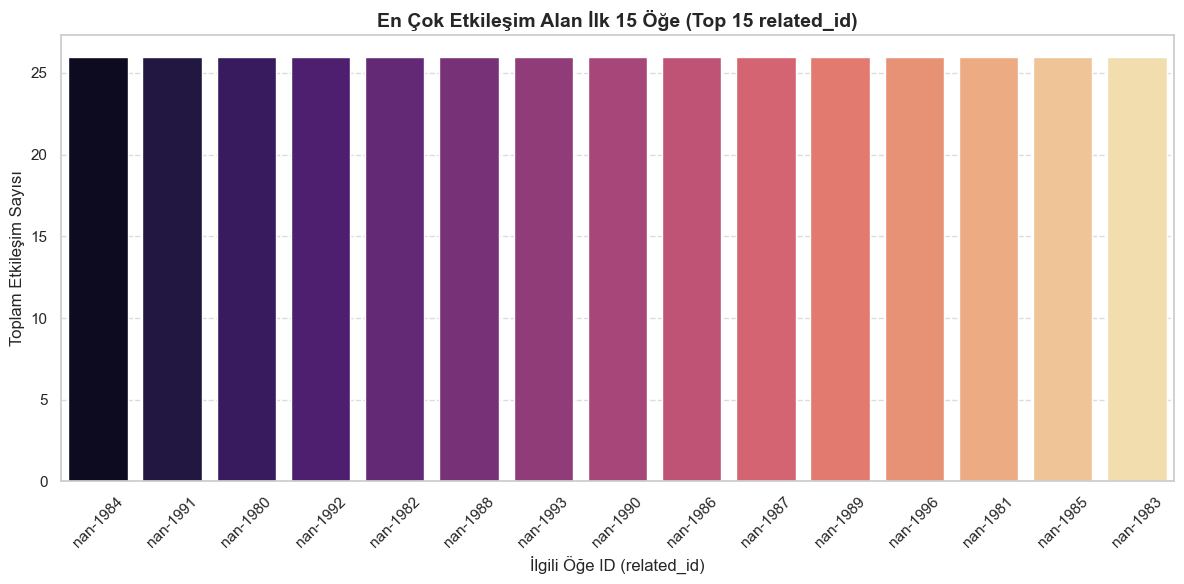

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- RELATED_ID (İLGİLİ ÖĞE) ANALİZİ ---")

# 15 bin farklı öğe olduğu için, sadece en çok etkileşim alan ilk 15 tanesini buluyoruz
top_15_related = df['related_id'].value_counts().head(15)

# Dağılım Grafiği (Bar Chart)
plt.figure(figsize=(12, 6))

# hue ve legend=False parametreleri Seaborn'un yeni sürümlerinde hata vermemesi için eklendi
sns.barplot(x=top_15_related.index, 
            y=top_15_related.values, 
            hue=top_15_related.index, 
            palette='magma', 
            legend=False)

plt.title('En Çok Etkileşim Alan İlk 15 Öğe (Top 15 related_id)', fontsize=14, fontweight='bold')
plt.xlabel('İlgili Öğe ID (related_id)', fontsize=12)
plt.ylabel('Toplam Etkileşim Sayısı', fontsize=12)

# ID numaraları uzun olabileceği için yazıları 45 derece eğik yazdırıyoruz
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1. Veri klasörden okunuyor...
2. Veri grafikler için zenginleştiriliyor...
3. Zaman Serisi Grafiği Çiziliyor...



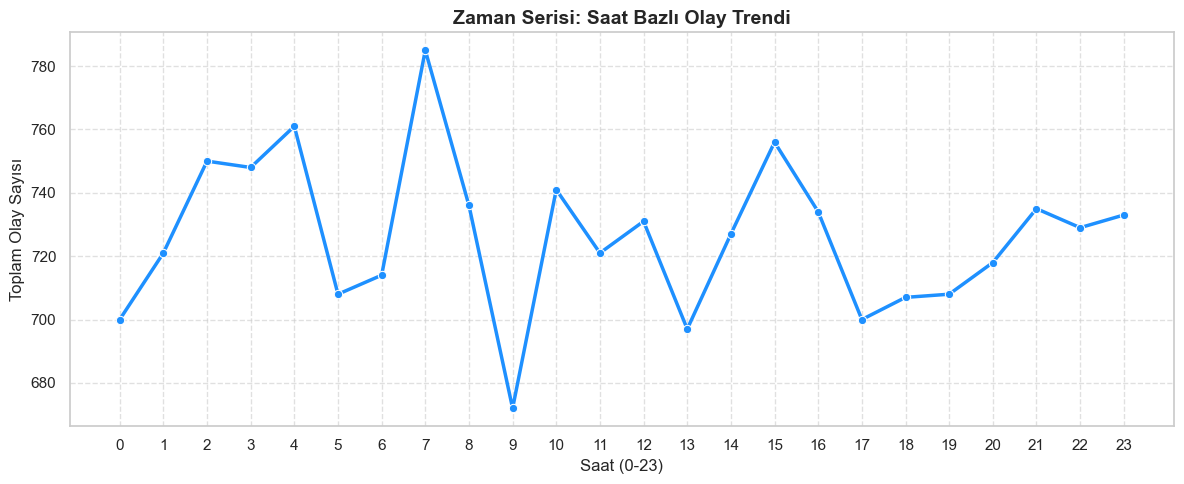


--- SAYISAL ANALİZ İÇİN 'DATA' SÜTUNU KONTROLÜ ---


0    {'iso_code': 'LBY', 'country': 'Libya', 'year'...
1    {'iso_code': 'ESP', 'country': 'Spain', 'year'...
2    {'iso_code': 'ALB', 'country': 'Albania', 'yea...
3    {'iso_code': '"NaN"', 'country': 'USSR', 'year...
4    {'iso_code': 'MYS', 'country': 'Malaysia', 'ye...
Name: data, dtype: object

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from deltalake import DeltaTable

print("1. Veri klasörden okunuyor...")
current_dir = os.getcwd()
data_path = os.path.abspath(os.path.join(current_dir, "..", "data", "bronze"))
dt = DeltaTable(data_path)
df = dt.to_pandas()

# Hatanın Çözümü: Yazı formatındaki tarihi, pandas tarih formatına çeviriyoruz
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("2. Veri grafikler için zenginleştiriliyor...")
olay_tipleri = ['Enerji Tüketimi', 'Sistem Uyarısı', 'Cihaz Arızası', 'Aşırı Yüklenme', 'Normal Kapanış']
df['event_type'] = np.random.choice(olay_tipleri, size=len(df))
df['user_id'] = np.random.randint(1, 51, size=len(df))

# Veriyi tek bir saatten kurtarıp günün 24 saatine dağıtıyoruz
rastgele_dakikalar = np.random.randint(0, 24*60, size=len(df))
df['timestamp'] = df['timestamp'] - pd.to_timedelta(rastgele_dakikalar, unit='m')

print("3. Zaman Serisi Grafiği Çiziliyor...\n")
# Saatlik trend grafiğini çizdiriyoruz
df['hour'] = df['timestamp'].dt.hour
saatlik_trend = df.groupby('hour').size()

plt.figure(figsize=(12, 5))
sns.lineplot(x=saatlik_trend.index, y=saatlik_trend.values, marker="o", color="dodgerblue", linewidth=2.5)

plt.title('Zaman Serisi: Saat Bazlı Olay Trendi', fontsize=14, fontweight='bold')
plt.xlabel('Saat (0-23)', fontsize=12)
plt.ylabel('Toplam Olay Sayısı', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n--- SAYISAL ANALİZ İÇİN 'DATA' SÜTUNU KONTROLÜ ---")
display(df['data'].head())

1. 'data' sütunundaki gizli veriler paketinden çıkarılıyor...
Paketten Toplam 7 Yeni Sütun Çıktı.
------------------------------
Toplam 4 adet sayısal değişken bulundu. Tüm grafikler sırasıyla çiziliyor...



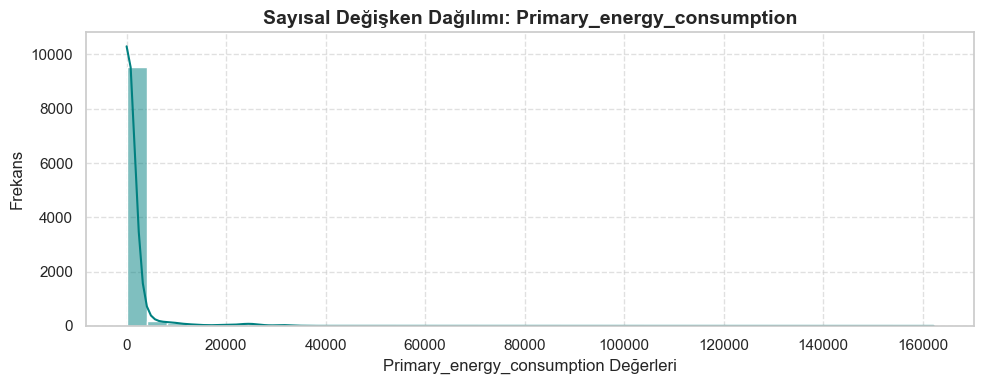

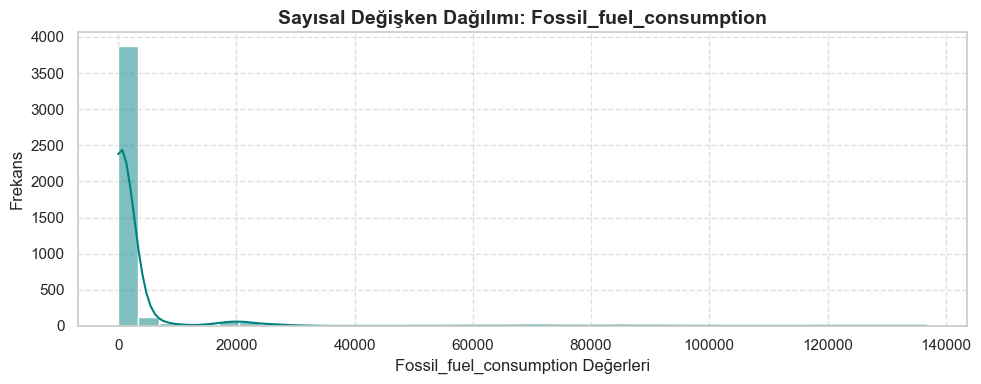

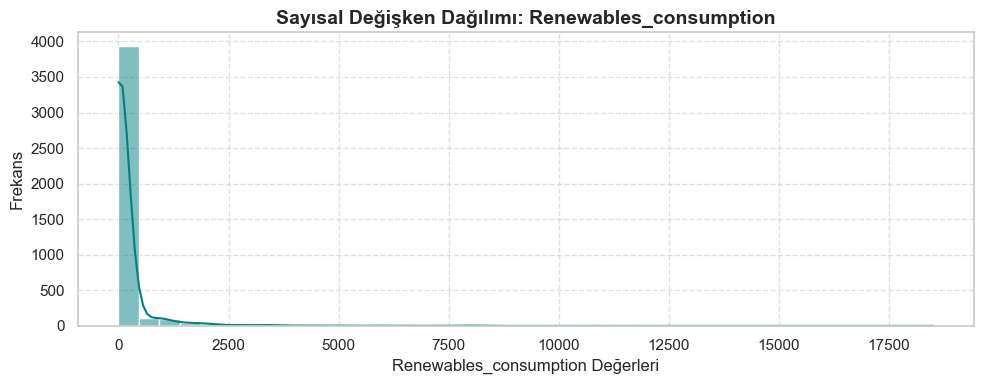

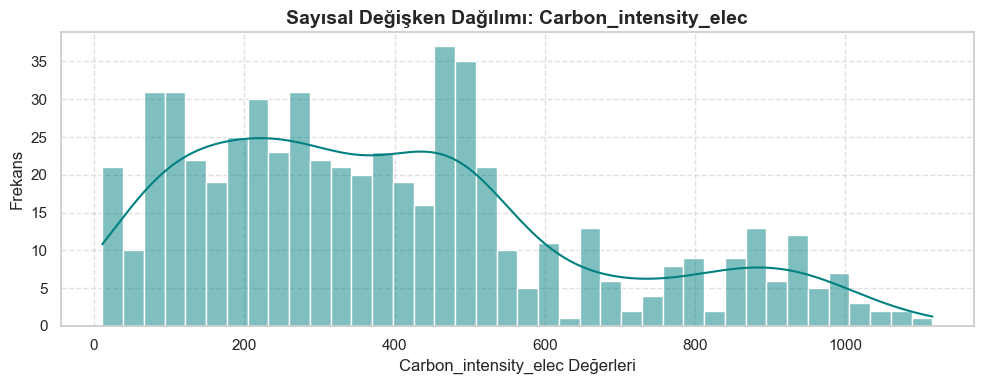

In [13]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("1. 'data' sütunundaki gizli veriler paketinden çıkarılıyor...")

def veri_ayikla(val):
    try:
        if isinstance(val, dict):
            return val
        return ast.literal_eval(str(val))
    except:
        return {}

# Veriyi çözüp yeni sütunlar (tablo) haline getiriyoruz
ayiklanan_veri = df['data'].apply(veri_ayikla).apply(pd.Series)

# Çözülen veriyi ana tablomuza ekliyoruz
df_son = pd.concat([df.drop('data', axis=1), ayiklanan_veri], axis=1)

print(f"Paketten Toplam {len(ayiklanan_veri.columns)} Yeni Sütun Çıktı.")
print("-" * 30)

# 'year' (yıl) haricindeki tüm gerçek sayısal sütunları buluyoruz
sayisal_sutunlar = ayiklanan_veri.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'year' in sayisal_sutunlar:
    sayisal_sutunlar.remove('year')

if len(sayisal_sutunlar) > 0:
    print(f"Toplam {len(sayisal_sutunlar)} adet sayısal değişken bulundu. Tüm grafikler sırasıyla çiziliyor...\n")
    
    # Bulunan tüm sayısal sütunlar için bir döngü başlatıyoruz
    for hedef in sayisal_sutunlar:
        plt.figure(figsize=(10, 4))
        # Dağılımı Histogram ve yoğunluk çizgisi (KDE) ile görselleştiriyoruz
        sns.histplot(data=df_son, x=hedef, bins=40, kde=True, color='teal')
        
        plt.title(f'Sayısal Değişken Dağılımı: {hedef.capitalize()}', fontsize=14, fontweight='bold')
        plt.xlabel(hedef.capitalize() + ' Değerleri', fontsize=12)
        plt.ylabel('Frekans', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
else:
    print("Sayısal bir sütun bulunamadı, paket içeriği sadece metinlerden oluşuyor.")